# Predicting customer churn risk with XGBoost

## Imports

In [1]:
from shutil import rmtree

import pandas as pd
import numpy as np
import opendatasets as od
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

## Data Loading

Note: only execute cell below once. The dataset will be available in telco-customer-churn folder.
The dataset comes from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

I am using `opendatasets` library for downloading datasets from Kaggle.

To learn more go to this link: https://pypi.org/project/opendatasets/

In [3]:
# Download the dataset
dataset_url = 'https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data'
od.download(dataset_url)

# Load the dataframe
df = pd.read_csv('telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


100%|██████████| 172k/172k [00:00<00:00, 3.10MB/s]

In [2]:
# Load the dataframe
df = pd.read_csv('telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


No NaN values in the dataset

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now we must check for hidden NaN values, such as missing_values = [' ', 'N/A', 'NA', 'nan']

### Auditing the dataset

Define the auditing function.

In [9]:
def audit_dataset(df):
    # Define common "stealth" missing value strings
    missing_variants = [' ', '', 'N/A', 'NA', 'None', 'null', 'nan']

    report = []

    for col in df.columns:
        # 1. Count standard NaNs
        standard_nans = df[col].isnull().sum()

        # 2. Count "Stealth" missing values (only for object/string columns)
        stealth_nans = 0
        if df[col].dtype == 'object':
            # Strip whitespace and check against our list
            stealth_nans = df[col].astype(str).str.strip().isin(missing_variants).sum()

        report.append({
            'Column': col,
            'Standard_NaN': standard_nans,
            'Stealth_NaN': stealth_nans,
            'Total_Missing': standard_nans + stealth_nans,
            'Dtype': df[col].dtype
        })

    return pd.DataFrame(report)

# Run the audit
audit_results = audit_dataset(df)
print(audit_results[audit_results['Total_Missing'] > 0])

          Column  Standard_NaN  Stealth_NaN  Total_Missing   Dtype
19  TotalCharges             0           11             11  object


In [16]:
df['TotalCharges'].dtype

dtype('float64')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

Call function to check the entire dataset to identify columns with hidden missing values.

In [10]:
audit_results = audit_dataset(df)
print(audit_results[audit_results['Total_Missing'] > 0])

          Column  Standard_NaN  Stealth_NaN  Total_Missing   Dtype
19  TotalCharges             0           11             11  object


In [11]:
df.shape

(7043, 21)

We see that there are indeed 11 'stealth NaNs' in the `TotalCharges` column. These NaNs are just 15% of data, we can safely drop them. Remember, by default `df.dropna` targets rows, which is what we want.

* We convert a column to float
* Replace ' ' with actual NaN data type.
* Drop NaN using `df.dropna`

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# STEP 2: Now dropna will actually "see" the 11 missing values
df.dropna(subset=['TotalCharges'], inplace=True)

# STEP 3: Verify the shape again
print(f"New shape: {df.shape}")
# It should now be 7032 rows (7043 - 11)

New shape: (7032, 21)


### Look for correlation between numeric features

We must avoid multicollinearity that will confuse the model. Here we check for correlation between numerical features.

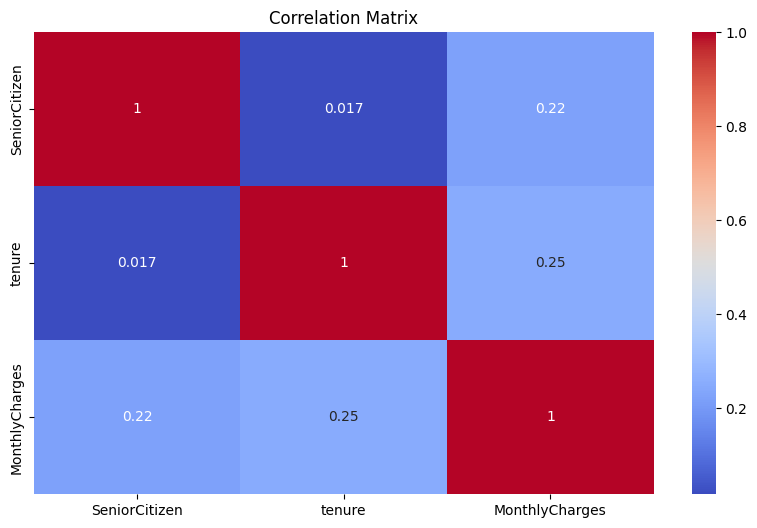

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check correlation of numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

None of the numerical features are highly correlated. The correlation coefficient is very low 0.017 - 0.25 We can keep all numerical features and avoid multicollinearity.

In [19]:
# --- DATA CLEANING ---

# The 'Churn' column is currently 'Yes'/'No'. XGBoost needs numbers (1/0).
# Write code to map 'Yes' to 1 and 'No' to 0.
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop the CustomerID column as it is not a feature
df.drop(columns=['customerID'], inplace=True)

print(f"Data Loaded. Shape: {df.shape}")
df.head()

Data Loaded. Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


If we wanted to use `apply()` function - which is slower - for target encoding, we would have called it on a Series to make sure x is an individual value:

`df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)`

## Data transformation (feature encoding and scaling)

Before passing the data to the ML model, we must encode all categorical features and standardize all numerical features. We will use `Pipeline` object with steps to take it.

To scale numerical features, we will use `StandardScaler`. It will transform numerical features so that they have value between 0 and 1. This method is more roust to outliers in the data. The `TotalCharges` or `MonthlyChargers` columns are likely to contain outliers.

Technically, we don't have to perform feature scaling as the XGBoost model will handle it automatically. However, it is good practice to do it in case we switch to a model that is sensitive to unscaled data.

About using: We can use OneHotEncoder and avoid the dimensionality blow-up on our data. We have 15 categorical column and 2-3 values per columns. In the end we will have ~50 binary columns, which is reasonable for a diverse dataset.



In [25]:
# 1. Split Features and Target
X = df.drop(columns=['Churn'])
y = df['Churn']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Define Column Selectors
# IMPORTANT: select_dtypes will return the subset of dataframe.
# We need to convert this to list
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# 4. Define Transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Use handle_unknown='ignore' to avoid crashing on new data in production. Unknown values will be treated as zeros.
# If column has just two values having a column of 0s and 1s is enough for encoding. No need for 2 columns
categorical_transformer = Pipeline(steps=[
    ('oh-encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

# 5. Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Numerical features: 4
Categorical features: 15


Sanity check: we must have a total of 19 features.
We reserved 'Churn' column as a label and dropped the index column. So we have 21 = 19 + 1 + 1 columns total.

## Training a model

In [26]:
import tempfile
# 1. Define the Model
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# Create a temporary directory to cache
cachedir = tempfile.mkdtemp()

# 2. Create the Full Pipeline.
# Use memory=cachedir to avoid preprocessing data
# for every run of Cross Validation
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
], memory=cachedir)

# 3. Define Hyperparameters for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 200],

    'classifier__max_depth': [3, 5, 7],

    'classifier__learning_rate': [0.01, 0.05, 0.1]
}

Perform Grid Search

In [27]:
# 4. Run GridSearch
grid_search = GridSearchCV(estimator=clf_pipeline, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Starting training... (this might take a moment)")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Starting training... (this might take a moment)
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


Clean up cached directory when training is complete

In [ ]:
rmtree(cachedir)

## Model evaluation

In [28]:
# Predict on Test Data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save the Pipeline
# We save the pipeline, not just the model, so preprocessing is saved too!
joblib.dump(best_model, 'churn_pipeline.joblib')
print("Pipeline saved successfully!")

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

Pipeline saved successfully!


For context:
* 0 means "Stayed"
* 1 means "Churned"

Then deploy the model using FastAPI. Tutorial here:
https://www.youtube.com/watch?v=x57vAQdBohQ&start=0

### Plot the confusion matrix

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def plot_confmat():
    labels = ['Stayed', 'Left (Churned)']

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True,
                fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

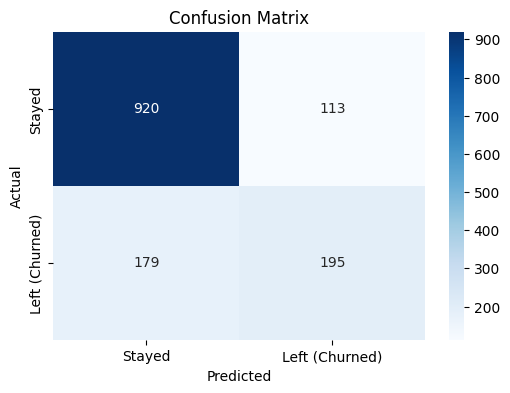

In [34]:
labels = ['Stayed', 'Left (Churned)']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,
            fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Confusion matrix interpretation

**Recall**: If the model predicts the customer will churn, is that prediction correct?

* Model caught 52% of the people who left.
* We missed 48% of people who left. We thought they stayed but they left. ("False Negative")
This is not good: the customers are leaving but the model doesn't notice it.

**Precision**: If the model predicts the customer will stay, is that prediction correct?

* 63% of the customers model flagged as "leaving" actually left.
* We marked 37% of people as leaving, but they stayed ("False Positive").

We want to be more accurate in predicting if the customer leaves so that we can give them incentives to stay. Hence, we should aim for higher recall.

# Experimentation & Model Improvement

In [38]:
counts = y_train.value_counts()
weight = counts[0] / counts[1]
print(weight)

2.762541806020067


In [47]:
from sklearn.metrics import recall_score, precision_score

# 1. Manual Weight Calculation
counts = y_train.value_counts()
weight = counts[0] / counts[1]

# 2. Train Model A (Unweighted)
model_unweighted = XGBClassifier(eval_metric='logloss', scale_pos_weight=1, random_state=42)
# We have to manually preprocess X_train here since we are bypassing the pipeline for the test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
model_unweighted.fit(X_train_transformed, y_train)

# 3. Train Model B (Weighted)
model_weighted = XGBClassifier(eval_metric='logloss', scale_pos_weight=weight, random_state=42)
model_weighted.fit(X_train_transformed, y_train)

# 4. Compare Recall
recall_a = recall_score(y_test, model_unweighted.predict(X_test_transformed))
recall_b = recall_score(y_test, model_weighted.predict(X_test_transformed))

print(f"Recall (Unweighted): {recall_a:.4f}")
print(f"Recall (Weighted):   {recall_b:.4f}")
print(type(X_train_transformed))

Recall (Unweighted): 0.5294
Recall (Weighted):   0.6711
<class 'numpy.ndarray'>


## The cell with the reset, try training a model with weight

In a Jupyter Notebook, when we define a variable like preprocessor, it lives in your computer's memory forever until you restart the kernel. When we ran the first weighted pipeline, we  passed it a preprocessor object that had already been "trained" or "fitted" during previous GridSearchCV or earlier experiments.

Even though we called `.fit()` on the new pipeline, the internal components sometimes carry a stale state from those previous runs. Hence we must create a fresh transformation of the data right before the model saw it, which is why it worked there.

In [48]:
from sklearn.model_selection import GridSearchCV

# 1. COMPLETELY RE-INITIALIZE TRANSFORMERS (Clears all "ghost" state)
numeric_transformer_final = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer_final = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor_final = ColumnTransformer(transformers=[
    ('num', numeric_transformer_final, numeric_features),
    ('cat', categorical_transformer_final, categorical_features)
])

# 2. CALCULATE WEIGHT
counts = y_train.value_counts()
weight = counts[0] / counts[1]

# 3. DEFINE WEIGHTED MODEL
xgb_weighted = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=weight,
    random_state=42
)

# 4. BUILD PIPELINE
clf_pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('classifier', xgb_weighted)
])

# 5. DEFINE PARAM GRID
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1]
}

# 6. RUN GRID SEARCH (Scoring for Recall!)
grid_search_final = GridSearchCV(
    clf_pipeline_final,
    param_grid,
    cv=5,
    scoring='recall', # We want to catch churners!
    n_jobs=-1,
)

print("Starting Weighted Grid Search...")
grid_search_final.fit(X_train, y_train)

# 7. Create classification report for the best model
best_model = grid_search_final.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest Parameters: {grid_search_final.best_params_}")
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred))

Starting Weighted Grid Search...

Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}

Final Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.72      0.74      1407



Save the best pipeline. What `best_estimator_` remembers:
* The Scaler: Remembers the exact mean and standard deviation of the training data.
* The Encoder: Remembers which numbers correspond to which categories (e.g., "Fiber Optic" = 1).
* The XGBoost Model: The actual decision trees.

In [51]:
joblib.dump(best_model, 'churn_pipeline.joblib')

['churn_pipeline.joblib']

Wrap the model training inside the function which has local scope. Even if we had a variable globally, the function creates its internal version. The training function is defined below.

In [ ]:
import joblib
from sklearn.base import clone

def train_champion_model(X_train, y_train, numeric_features, categorical_features):
    """
    Trains a weighted XGBoost model using a fresh pipeline to avoid Jupyter stale state.
    """
    # 1. Re-initialize Transformers from scratch
    num_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('oh-encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
    ])

    # 2. Build the Preprocessor
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ])

    # 3. Calculate Weight (Scale for Imbalance)
    counts = y_train.value_counts()
    weight = counts[0] / counts[1]

    # 4. Define Model & Pipeline
    xgb_model = XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=weight,
        random_state=42
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ])

    # 5. Define Search Grid
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 4, 5],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }

    # 6. Grid Search for Recall
    # Using 'recall' ensures we focus on the 82% target you hit!
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='recall',
        n_jobs=-1
    )

    print("Training the model...")
    grid_search.fit(X_train, y_train)

    # 7. Save and Return the Best Estimator
    best_pipeline = grid_search.best_estimator_
    joblib.dump(best_pipeline, 'churn_pipeline.joblib')

    print("Model trained and saved successfully.")
    return best_pipeline, grid_search.best_params_

## Visualize weighted model predictions

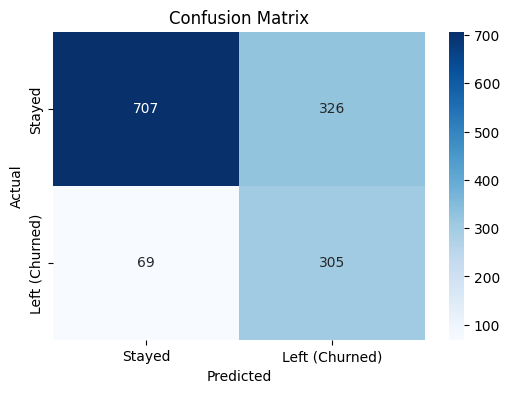

In [50]:
plot_confmat()

* We correctly identified ~82% of people who left
* We correctly identified ~68% of people who stayed

## Extract most important features

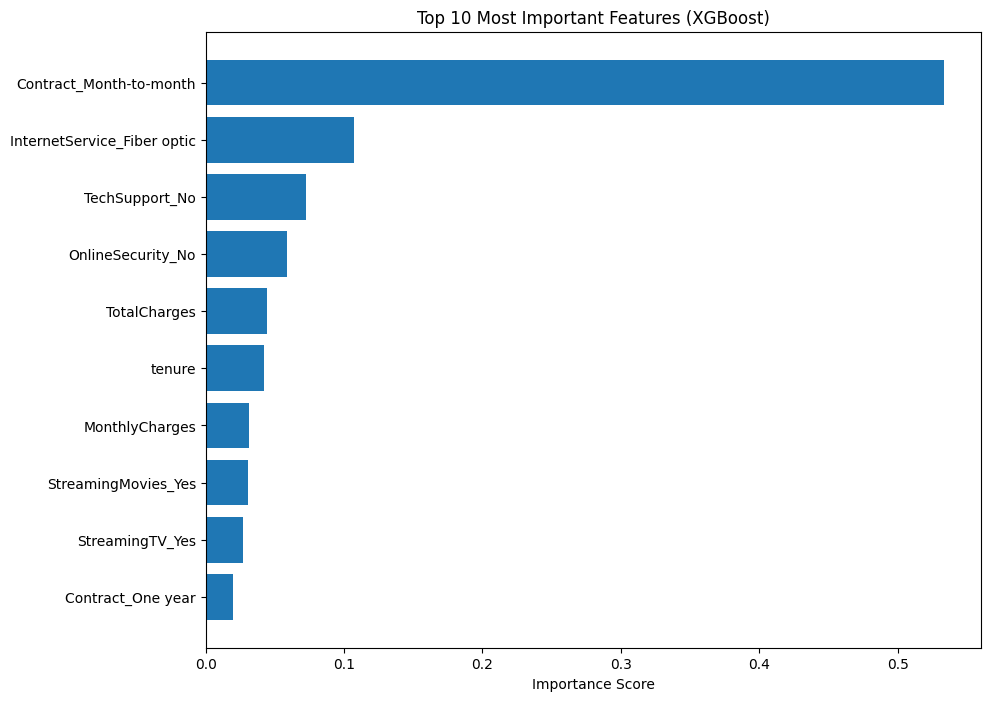

In [54]:
import numpy as np

# Encoder was named 'onehot' before we defined a function
# Change to 'oh-encoder' if the model was trained using the function
encoder = 'onehot'

model_step = best_model.named_steps['classifier']
preprocessor_step = best_model.named_steps['preprocessor']

ohe_feature_names = preprocessor_step.named_transformers_['cat'].named_steps[encoder].get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([numeric_features, ohe_feature_names])

importances = model_step.feature_importances_
feature_importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# 4. Plot the results
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'][:10], feature_importance_df['importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Most Important Features (XGBoost)')
plt.xlabel('Importance Score')
plt.show()